<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_4_5_MLR_Ames_Part5_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 5
## Tree-Based Methods

**Author:** Brad Sheese

In Parts 1-4, we mostly focussed on Linear Models. (There was a brief foray into capturing non-linear patterns using polynomial features.)  

In this notebook we will explore Tree-Based Models (Decision Trees, Random Forests, and Gradient Boosting) which learn by asking a series of Yes/No questions to split the data, allowing them to capture complex, non-linear patterns automatically.

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data source
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'
df_raw = pd.read_csv(url, sep='\t')

# Initial cleaning
df = df_raw.loc[df_raw['Gr Liv Area'] < 4000, :].copy()
df.loc[df['Garage Yr Blt'] > 2010, 'Garage Yr Blt'] = 2010

# Helper function
def safe_drop(df: pd.DataFrame, drop_list: list[str]) -> pd.DataFrame:
    existing_cols_to_drop = [col for col in drop_list if col in df.columns]
    if existing_cols_to_drop:
        df = df.drop(existing_cols_to_drop, axis=1)
    return df

# --- Compressed Cleaning Logic (Matches Part 3) ---

# 1. Create Flags
df['garage_attached'] = np.where(df['Garage Type'] == 'Attchd', 1, 0)
df['garage_unfinished'] = np.where(df['Garage Finish'] != 'Unf', 1, 0)

# 2. Consolidated Drop List
drop_list = [
    'Order', 'PID', 'Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val',
    'Alley', 'Fence', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
    'BsmtFin Type 1', 'BsmtFin Type 2', 'Fireplace Qu', 'Neighborhood',
    'MS Subclass', 'Mo Sold', 'Kitchen Qual', 'Exter Qual', 'Heating QC',
    'Garage Qual', 'Garage Cond', 'Garage Type', 'Garage Finish', 'Street',
    'Land Contour', 'Utilities', 'Land Slope', 'Condition 1', 'Condition 2',
    'Roof Matl', 'Exter Cond', 'Heating', 'Central Air', 'Electrical',
    'Functional', 'Paved Drive', 'Sale Type', 'Exterior 1st', 'Exterior 2nd',
    'Mas Vnr Area'
]
df = safe_drop(df, drop_list)

# 3. Collapse High Cardinality Categoricals
for col in df.select_dtypes(include=['object']).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.50:
    top_value = (df[col].value_counts(normalize=True, dropna=False).index[0])
    df[col + '_' + top_value] = np.where(df[col] == top_value, 1, 0)
    df = safe_drop(df, [col])

# 4. Handle Foundation & Types
df.loc[~df['Foundation'].isin(['PConc', 'CBlock']), 'Foundation'] = 'Other'

for col in df.select_dtypes('object').columns:
  df[col] = df[col].astype('category')

for col in df.columns:
  if df[col].value_counts().shape[0] == 2:
    df[col] = df[col].astype('bool')

# 5. Drop Highly Uniform Numerics
for col in df.select_dtypes(include=np.number).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.90:
    df = safe_drop(df, [col])

# 6. Booleanize Sparse Numerics
for col in df.select_dtypes(include=np.number).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.80:
    if len(df[col].unique()) > 2:
      df[col] = np.where(df[col] > 0, 1, 0)
    df[col] = df[col].astype('boolean')

# 7. Impute Missing Values
num_cols_with_na = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()
for col in num_cols_with_na:
    df[col] = df[col].fillna(df[col].median())

# 8. One-Hot Encoding
df = pd.get_dummies(df, columns=df.select_dtypes(include='category').columns, drop_first=True)

print(f"Final dataframe shape: {df.shape}")

Final dataframe shape: (2925, 39)


In [2]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['SalePrice'])
y = df['SalePrice'].map(np.log)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Setup complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Setup complete. Train shape: (2340, 38), Test shape: (585, 38)


## 1. Why Tree-Based Methods?

Linear regression models calculate a single global slope for each feature. But real-world data is often "non-linear."

For example:
*   **Diminishing Returns**: Increasing `Garage Area` from 0 to 400 sq ft adds a lot of value. Increasing it from 1000 to 1400 adds much less.
*   **Threshold Effects**: Houses built *after* a certain year might command a specific premium due to building codes or styles.
*   **Interactions**: `Overall Qual` might matter more in certain neighborhoods than others.

Trees handle these scenarios automatically by splitting the data into subsets.

## 2. Decision Tree Regressor

Think of a Decision Tree like a game of "20 Questions." The model tries to predict the price by asking a series of binary questions:
1.  "Is the House larger than 2,000 sq ft?" (Yes/No)
2.  "Is the Overall Quality greater than 7?" (Yes/No)
3.  "Does it have a finished basement?" (Yes/No)

It keeps splitting the data into smaller and smaller buckets until it makes a prediction (the average price of the houses in that bucket).

### The Danger: Overfitting
If we don't stop it, the tree will keep asking questions until it memorizes every single house in the training set. It will have a separate leaf for every unique house. This creates a model that scores 100% on the training exam but fails the real-world test.

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# 1. Unconstrained Tree (The "Memorizer")
dt_overfit = DecisionTreeRegressor(random_state=42) # No max_depth limit
dt_overfit.fit(X_train, y_train)

# 2. Constrained Tree (The "Generalizer")
dt_limited = DecisionTreeRegressor(max_depth=5, random_state=42) # Limit to 5 questions deep
dt_limited.fit(X_train, y_train)

print("--- UNCONSTRAINED Tree ---")
print(f"Training R²: {dt_overfit.score(X_train, y_train):.4f} (Perfect memory)")
print(f"Test R²:     {dt_overfit.score(X_test, y_test):.4f} (Fails to generalize)")
print("\n--- LIMITED Tree (Depth=5) ---")
print(f"Training R²: {dt_limited.score(X_train, y_train):.4f}")
print(f"Test R²:     {dt_limited.score(X_test, y_test):.4f} (Better generalization)")

--- UNCONSTRAINED Tree ---
Training R²: 1.0000 (Perfect memory)
Test R²:     0.7863 (Fails to generalize)

--- LIMITED Tree (Depth=5) ---
Training R²: 0.8268
Test R²:     0.8171 (Better generalization)


## 3. Random Forests (Bagging)

If one decision tree is prone to errors, what is the solution? **Democracy.**

A Random Forest builds hundreds of *independent* decision trees.
1.  **Random Data:** Each tree is trained on a random subset of the data (bootstrapping).
2.  **Random Features:** At every split, the tree can only look at a random subset of features.

Because each tree sees the data slightly differently, they make different mistakes. When we average their predictions together, the errors cancel out, leaving us with a robust, stable prediction.

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def tune_model(model, param_grid, X_train, y_train):
    """
    Generic function to perform GridSearchCV.
    Note: For Trees, scaling is NOT technically required, but we include it in the pipeline
    for consistency with our Part 4 linear models.
    """
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline_param_grid = {f'model__{key}': value for key, value in param_grid.items()}

    grid_search = GridSearchCV(
        pipeline, pipeline_param_grid, cv=5, scoring='r2', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV R²: {grid_search.best_score_:.4f}")
    return grid_search.best_estimator_

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None], # note that None max depth means there is not limit
    'max_features': [1.0, 'sqrt']
}

print("--- Tuning Random Forest ---")
best_rf = tune_model(RandomForestRegressor(random_state=42), rf_params, X_train, y_train)

--- Tuning Random Forest ---
Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
Best CV R²: 0.8763


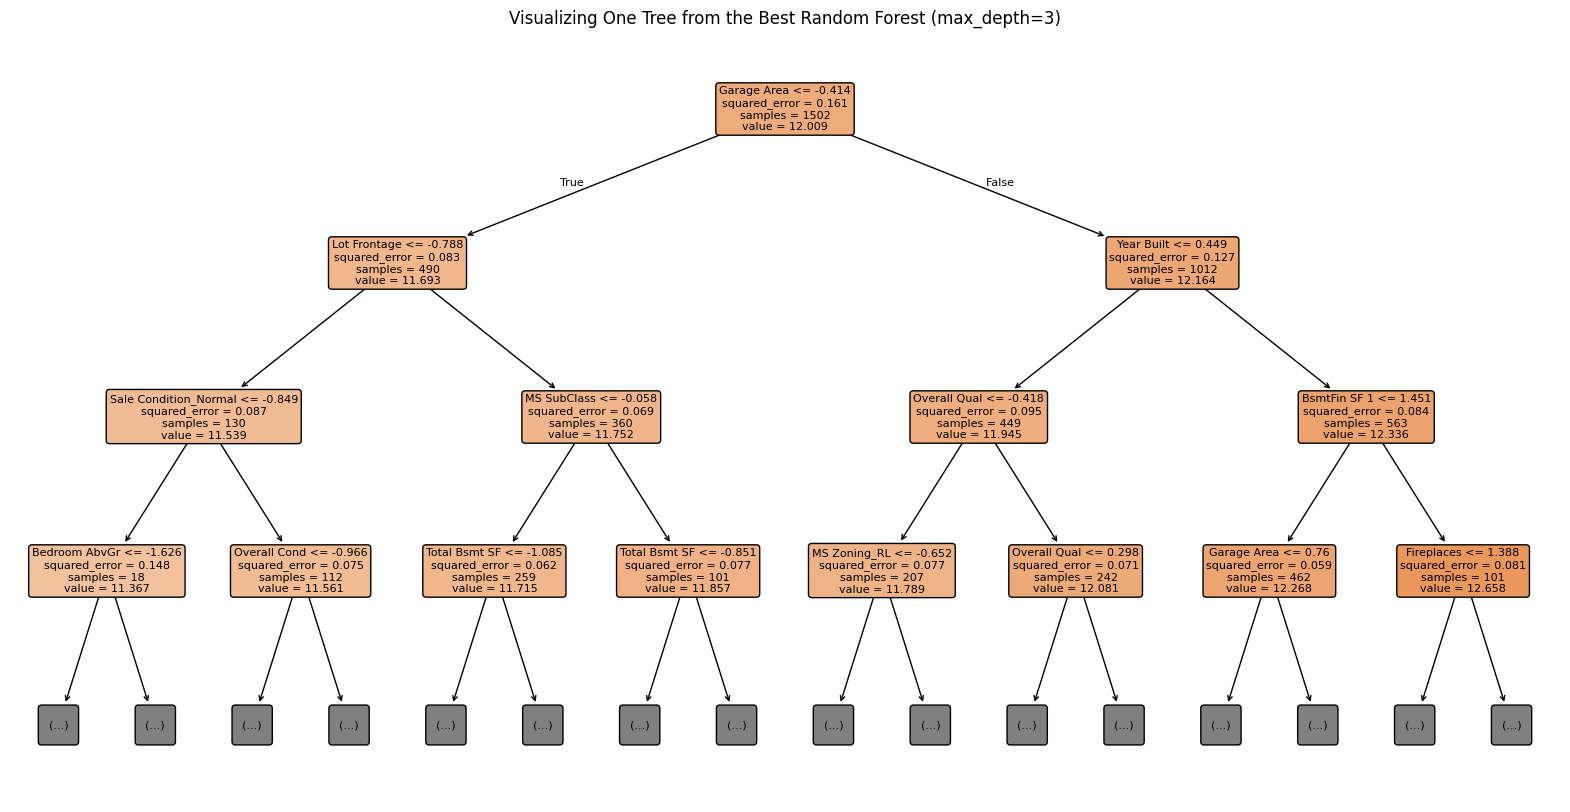

In [6]:
# tree visualization based on first tree from result

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the best Random Forest Regressor model from the pipeline
rf_model = best_rf.named_steps['model']

# Select one of the estimators (trees) from the forest to visualize
# For example, the first tree
single_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
plot_tree(single_tree,
          feature_names=X_train.columns.tolist(), # Use feature names from the training data
          filled=True, # Color nodes to indicate the majority class (or value for regression)
          rounded=True, # Round node corners
          max_depth=3, # Limit the depth for better visualization (full trees can be very deep)
          fontsize=8)
plt.title("Visualizing One Tree from the Best Random Forest (max_depth=3)")
plt.show()

This visualization shows one of the many decision trees within the Random Forest model. Each node represents a decision rule based on a feature, and the leaves represent the predicted value for that segment of the data. Notice that the `max_depth` for visualization is limited to 3 to keep the plot readable, as the actual trees in the `best_rf` are much deeper.

## 4. Gradient Boosting

While Random Forest builds trees in parallel (independently), Gradient Boosting builds them **sequentially**.

1.  Tree 1 makes a prediction.
2.  Tree 2 looks at the **errors** (residuals) of Tree 1 and tries to fix them.
3.  Tree 3 looks at the remaining errors from Tree 2 and tries to fix those.

It is like a team of developers where each person focuses specifically on fixing the bugs left by the previous person. This often results in the highest possible accuracy for tabular data.

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5]
}

print("--- Tuning Gradient Boosting ---")
best_gb = tune_model(HistGradientBoostingRegressor(random_state=42), gb_params, X_train, y_train)

--- Tuning Gradient Boosting ---
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300}
Best CV R²: 0.8932


## 5. Feature Importance

Unlike coefficients in linear regression, tree models provide a "Feature Importance" score based on how much each feature contributed to reducing error across all trees.

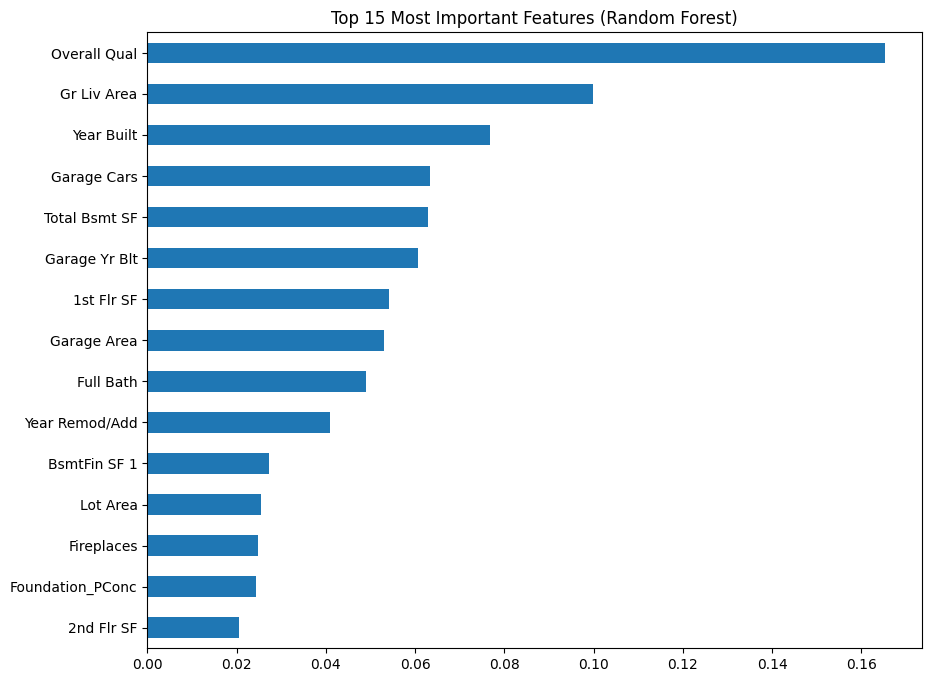

In [ ]:
# Extract importance from the best Random Forest model
importances = best_rf.named_steps['model'].feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(15).plot(kind='barh')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

## 6. The Grand Finale: Linear vs. Non-Linear

Let's compare our best tree-based models against a quick optimized Lasso model (from Part 4) to see the final leaderboard.

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# 1. Re-run a quick Optimized Lasso (Linear Representative)
# We use a small grid here just to get a representative linear model
lasso_params = {'alpha': [0.0001, 0.001, 0.01]}
best_lasso = tune_model(Lasso(max_iter=10000), lasso_params, X_train, y_train)

# 2. Compile Results
models = {
    'Optimized Lasso (Linear)': best_lasso,
    'Random Forest (Ensemble)': best_rf,
    'Gradient Boosting (Ensemble)': best_gb
}

results_list = []

print("\n--- FINAL SHOWDOWN ---")
for name, model in models.items():
    # Predict on unseen test data
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)

    results_list.append({
        'Model': name,
        'Test R²': r2,
        'Test MSE': mse
    })

# Display as a clean DataFrame
results_df = pd.DataFrame(results_list).sort_values(by='Test R²', ascending=False)
print(results_df.to_string(index=False, float_format="%.4f"))

Best Parameters: {'model__alpha': 0.001}
Best CV R²: 0.8903


,Model,Test R²,Test MSE
0,Optimized Lasso (Linear),0.9352,0.0112
1,Optimized Random Forest,0.9277,0.0125
2,Optimized Gradient Boosting,0.9443,0.0096


## Conclusion

1.  **Complexity Wins**: In most cases, Gradient Boosting or Random Forest will outperform Lasso/Ridge because they can capture non-linear patterns (like `Overall Qual` being exponentially important).
2.  **Trade-offs**: Tree models are "black boxes"—they don't give us a simple equation like $y = mx + b$. We trade interpretability for predictive power.
3.  **No Silver Bullet**: On small datasets or data that is truly linear, OLS or Lasso can still win. However, for real-world tabular data like the Ames dataset, Ensemble methods are the gold standard.